<a href="https://colab.research.google.com/github/Uli-Gonzalez/luzu-youtube-data-analysis-eda-vis/blob/main/LUZU_EDA_Vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

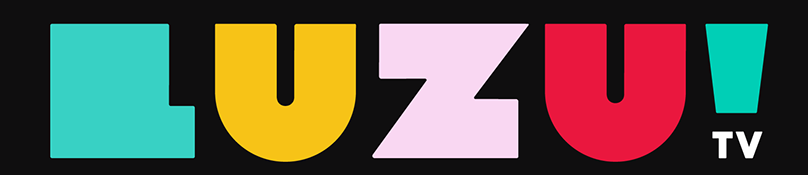

#**PROYECTO: Análisis de datos públicos del canal de streaming LUZU TV**

##**Objetivos del proyecto**

**Objetivo general**

- Desarrollar un proceso integral de análisis de datos sobre el canal de
streaming LUZU TV, utilizando información pública obtenida desde la API de YouTube, con el fin de estructurar, analizar y visualizar métricas clave que permitan comprender el desempeño del contenido y generar insights orientados a la toma de decisiones estratégicas.

**Objetivo específico 2**

**EDA (Exploratory Data Analysis)**

- El objetivo principal es identificar patrones de rendimiento, compromiso y comportamientos extremos de audiencia durante el año 2025, con foco en variables como vistas normalizadas, crecimiento inicial, formato, interacción y conversación.

Este análisis parte del dataset previamente construido en la etapa de ETL.

#**ANÁLISIS EXPLORATORIO DE DATOS (EDA)**

**Carga del dataframe**

In [1]:
import pandas as pd


In [2]:
# 1. Apertura del archivo .JSON, previamente descargado en el Notebook de ETL
df_luzu = pd.read_json(
    '/content/sample_data/luzu_clean_data.json',
    lines=True
)

In [3]:
# 2. Exploración del df_luzu
df_luzu.head(5)

,Title,Published At,Views,Likes,Comments,Title_norm,Duration_min,Days_since_published,Views_per_day,Views_per_min_norm,Like_ratio,Comments_ratio,Engagement_rate,Growth_factor,Outlier_views,Outlier_likes,Outlier_engagement,Programs,Video_format
0,OCCHIAMIN - ESPECIAL DE NAVIDAD 2025,1766609046000,385095,16973,669,occhiamin - especial de navidad 2025,452.60,1,385095.0,850.850641,0.044075,0.001737,0.045812,25452.025911,True,True,False,Contenido no programático,Complete programming
1,Lo que suena en cualquier hogar argentino en l...,1766515070000,20759,515,10,lo que suena en cualquier hogar argentino en l...,2.62,2,10379.5,3961.641221,0.024809,0.000482,0.025290,477.875594,False,False,False,Algo de música,Clip
2,Que pesadas las tías! #sefuelarga #luzutv,1766509943000,46912,1020,19,que pesadas las tias! #sefuelarga #luzutv,0.37,2,23456.0,63394.594595,0.021743,0.000405,0.022148,945.738556,False,False,False,Se fue larga,Short
3,"Por suerte, Estanislabio volvio #sefuelarga #l...",1766509909000,7395,137,1,"por suerte, estanislabio volvio #sefuelarga #l...",0.90,2,3697.5,4108.333333,0.018526,0.000135,0.018661,125.613013,False,False,False,Se fue larga,Short
4,Festejemos como podamos y queramos #sefuelarga...,1766509873000,7367,246,3,festejemos como podamos y queramos #sefuelarga...,1.27,2,3683.5,2900.393701,0.033392,0.000407,0.033799,226.649567,False,False,False,Se fue larga,Clip


In [4]:
# 2. Exploración del df_luzu. Se verifica columna "Published At" con datos del tipo int64
df_luzu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9915 entries, 0 to 9914
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Title                 9915 non-null   object 
 1   Published At          9915 non-null   int64  
 2   Views                 9915 non-null   int64  
 3   Likes                 9915 non-null   int64  
 4   Comments              9915 non-null   int64  
 5   Title_norm            9915 non-null   object 
 6   Duration_min          9915 non-null   float64
 7   Days_since_published  9915 non-null   int64  
 8   Views_per_day         9915 non-null   float64
 9   Views_per_min_norm    9915 non-null   float64
 10  Like_ratio            9915 non-null   float64
 11  Comments_ratio        9915 non-null   float64
 12  Engagement_rate       9915 non-null   float64
 13  Growth_factor         9915 non-null   float64
 14  Outlier_views         9915 non-null   bool   
 15  Outlier_likes        

In [5]:
# 3. Conversión correcta desde Unix timestamp en milisegundos
df_luzu['Published At'] = pd.to_datetime(df_luzu['Published At'], unit= 'ms')

In [6]:
# 4. Verificación de la modificación anterior
df_luzu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9915 entries, 0 to 9914
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Title                 9915 non-null   object        
 1   Published At          9915 non-null   datetime64[ns]
 2   Views                 9915 non-null   int64         
 3   Likes                 9915 non-null   int64         
 4   Comments              9915 non-null   int64         
 5   Title_norm            9915 non-null   object        
 6   Duration_min          9915 non-null   float64       
 7   Days_since_published  9915 non-null   int64         
 8   Views_per_day         9915 non-null   float64       
 9   Views_per_min_norm    9915 non-null   float64       
 10  Like_ratio            9915 non-null   float64       
 11  Comments_ratio        9915 non-null   float64       
 12  Engagement_rate       9915 non-null   float64       
 13  Growth_factor     

In [7]:
# 4. Verificación de la modificación anterior
df_luzu.head(5)

,Title,Published At,Views,Likes,Comments,Title_norm,Duration_min,Days_since_published,Views_per_day,Views_per_min_norm,Like_ratio,Comments_ratio,Engagement_rate,Growth_factor,Outlier_views,Outlier_likes,Outlier_engagement,Programs,Video_format
0,OCCHIAMIN - ESPECIAL DE NAVIDAD 2025,2025-12-24 20:44:06,385095,16973,669,occhiamin - especial de navidad 2025,452.60,1,385095.0,850.850641,0.044075,0.001737,0.045812,25452.025911,True,True,False,Contenido no programático,Complete programming
1,Lo que suena en cualquier hogar argentino en l...,2025-12-23 18:37:50,20759,515,10,lo que suena en cualquier hogar argentino en l...,2.62,2,10379.5,3961.641221,0.024809,0.000482,0.025290,477.875594,False,False,False,Algo de música,Clip
2,Que pesadas las tías! #sefuelarga #luzutv,2025-12-23 17:12:23,46912,1020,19,que pesadas las tias! #sefuelarga #luzutv,0.37,2,23456.0,63394.594595,0.021743,0.000405,0.022148,945.738556,False,False,False,Se fue larga,Short
3,"Por suerte, Estanislabio volvio #sefuelarga #l...",2025-12-23 17:11:49,7395,137,1,"por suerte, estanislabio volvio #sefuelarga #l...",0.90,2,3697.5,4108.333333,0.018526,0.000135,0.018661,125.613013,False,False,False,Se fue larga,Short
4,Festejemos como podamos y queramos #sefuelarga...,2025-12-23 17:11:13,7367,246,3,festejemos como podamos y queramos #sefuelarga...,1.27,2,3683.5,2900.393701,0.033392,0.000407,0.033799,226.649567,False,False,False,Se fue larga,Clip


Durante la primer etapa del EDA se normalizaron los timestamps provenientes de la API de YouTube, los cuales, luego de guardarse en el archivo.json, se encontraban en formato Unix (milisegundos), garantizando consistencia temporal para el análisis exploratorio.

##**Necesidad del negocio 1**

El foco de este estudio está puesto en los datos correspondientes al año 2025, buscando comprender las dinámicas recientes que explican los picos excepcionales de visualización y engagement del canal.

**Pregunta 1:** ¿Qué programas generan mayor tracción real en la audiencia?

📌 Necesidad del negocio:
Invertir más tiempo, presupuesto y talento en los programas que mejor rinden, no solo los más largos o frecuentes.

🔎 Preguntas clave

1.a ¿Qué programas tienen más vistas normalizadas? ¿Qué programas sostienen, mejoran o pierden tracción?

1.b ¿Cuáles crecen más rápido tras publicarse?

1.c ¿Qué programas mantienen mejor engagement?




Para evaluar la evolución del rendimiento por programa, se realizaron comparaciones interanuales (2024 vs 2025) utilizando métricas normalizadas. En el caso de métricas de crecimiento, se priorizó una ventana temporal corta (7 días) para evitar sesgos por antigüedad del contenido.

1.a ¿Qué programas tienen más vistas normalizadas? Ranking 2025

¿Qué programas sostienen, mejoran o pierden tracción? Comparativa interanual 2024-2025

In [8]:
# Elaboración de dos dataframes año 2024 y 2025 para la comparativa interanual y el ranking
df_luzu_2024 = df_luzu[
    (df_luzu['Published At'] >= '2024-01-01') &
    (df_luzu['Published At'] < '2025-01-01')
]

df_luzu_2025 = df_luzu[
    (df_luzu['Published At'] >= '2025-01-01')
]

In [9]:
# Revisión de la información contenida en df_luzu_2024
df_luzu_2024.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1709 entries, 4004 to 5712
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Title                 1709 non-null   object        
 1   Published At          1709 non-null   datetime64[ns]
 2   Views                 1709 non-null   int64         
 3   Likes                 1709 non-null   int64         
 4   Comments              1709 non-null   int64         
 5   Title_norm            1709 non-null   object        
 6   Duration_min          1709 non-null   float64       
 7   Days_since_published  1709 non-null   int64         
 8   Views_per_day         1709 non-null   float64       
 9   Views_per_min_norm    1709 non-null   float64       
 10  Like_ratio            1709 non-null   float64       
 11  Comments_ratio        1709 non-null   float64       
 12  Engagement_rate       1709 non-null   float64       
 13  Growth_factor       

In [10]:
# Revisión de la información contenida en df_luzu_2025
df_luzu_2025.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4004 entries, 0 to 4003
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Title                 4004 non-null   object        
 1   Published At          4004 non-null   datetime64[ns]
 2   Views                 4004 non-null   int64         
 3   Likes                 4004 non-null   int64         
 4   Comments              4004 non-null   int64         
 5   Title_norm            4004 non-null   object        
 6   Duration_min          4004 non-null   float64       
 7   Days_since_published  4004 non-null   int64         
 8   Views_per_day         4004 non-null   float64       
 9   Views_per_min_norm    4004 non-null   float64       
 10  Like_ratio            4004 non-null   float64       
 11  Comments_ratio        4004 non-null   float64       
 12  Engagement_rate       4004 non-null   float64       
 13  Growth_factor         4

In [11]:
# Obtención de las vistas normalizadas año 2024 y año 2025

views_2024 = (
    df_luzu_2024.groupby('Programs')['Views_per_day']
    .median()
    .sort_values(ascending=False)
)

views_2025 = (
    df_luzu_2025.groupby('Programs')['Views_per_day']
    .median()
    .sort_values(ascending=False)
)

In [12]:
views_2024

,Views_per_day
Programs,
Programación completa,1535.005063
Fresco y Batata,442.445494
Nadie dice nada,417.807453
Tarde de tertulia,245.247984
Así somos,226.405634
PLP,209.508353
Antes que nadie,133.185321
El reality de Nadie dice nada,128.421627
Luzu FC,124.877960


In [13]:
views_2025

,Views_per_day
Programs,
PLP,45161.300000
Programación completa,2730.849545
Nadie dice nada,1355.757533
Así somos,996.125000
Luzu kids,498.187500
Los no talentos,417.113821
Antes que nadie,348.428936
Edición especial,295.818182
Algo va a picar,268.882658


Los registros correspondientes a ‘Programación completa’ fueron excluidos del análisis, ya que este formato consolida múltiples programas diarios en un único video, acumulando visualizaciones que no pueden atribuirse a un programa específico. Además, los registros de "Contenido no programático" también fueron eliminados del análisis debido a la falta de especificidad de la información contenida. La inclusión de estos datos distorsiona la comparación de métricas de rendimiento por programa.

In [14]:
#Eliminación de registros 'Programación completa'

df_luzu_2024 = df_luzu_2024[
    ~df_luzu_2024['Programs'].isin([
        'Programación completa',
        'Contenido no programático'
    ])
]

df_luzu_2025 = df_luzu_2025[
    ~df_luzu_2025['Programs'].isin([
        'Programación completa',
        'Contenido no programático'
    ])
]

In [15]:
#Verificación de la eliminación anterior

df_luzu_2024['Programs'].unique()

array(['Tarde de tertulia', 'Patria y familia', 'Nada que no sepamos',
       'Nadie dice nada', 'Antes que nadie', 'Edición especial',
       'Algo de música', 'PLP', 'Duquesas', 'Así somos',
       'Fresco y Batata', 'FM Luzu', 'El reality de Nadie dice nada',
       'Entre nosotros', 'Un churrito', 'Pasión por la redonda',
       'Luzu FC', 'Red flag', 'Pachu stream master'], dtype=object)

In [16]:
#Verificación de la eliminación anterior

df_luzu_2025['Programs'].unique()

array(['Algo de música', 'Se fue larga', 'La novela', 'Los no talentos',
       'Patria y familia', 'Nadie dice nada', 'Antes que nadie',
       'Algo va a picar', 'Edición especial', 'Luzu kids',
       'Xtream master', 'PLP', 'Así somos',
       '15 prendas 15 preguntas con el trinche', 'FM Luzu',
       'El reality de Nadie dice nada', 'Flor Jazmín', 'Luzu FC',
       'Un churrito', 'Mañanas nostálgicas', 'Nada que no sepamos'],
      dtype=object)

In [17]:
# Búsqueda del programa "PLP" en views_2025. Se verifica una sola emisión a modo de programa especial.

df_luzu_2025[df_luzu_2025['Programs'] == 'PLP']

,Title,Published At,Views,Likes,Comments,Title_norm,Duration_min,Days_since_published,Views_per_day,Views_per_min_norm,Like_ratio,Comments_ratio,Engagement_rate,Growth_factor,Outlier_views,Outlier_likes,Outlier_engagement,Programs,Video_format
75,#PLP l DEL CAOS A LA CALMA: UNA VERDADERA NOCH...,2025-12-16 02:24:24,451613,28118,657,#plp l del caos a la calma: una verdadera noch...,129.27,10,45161.3,349.356386,0.062261,0.001455,0.063716,12000.107063,True,True,False,PLP,Full program


En el views_2025 se identificó un valor atípico correspondiente a un especial del programa PLP publicado recientemente, con un número reducido de días desde su publicación. Dado que este contenido no corresponde a un programa emitido con frecuencia y presenta una ventaja estructural por su corta ventana de visualización, fue excluido del análisis principal de rendimiento por programa. No obstante, se conserva para análisis específicos de outliers y eventos especiales.

In [18]:
# Se define un nuevo df_luzu_2025 denominado "core" que excluye el registro "PLP"

df_luzu_2025_core = df_luzu_2025[
    ~(df_luzu_2025["Programs"] == "PLP")
]

In [19]:
# Verificación de la eliminación anterior

df_luzu_2025_core[df_luzu_2025_core["Programs"] == "PLP"]

,Title,Published At,Views,Likes,Comments,Title_norm,Duration_min,Days_since_published,Views_per_day,Views_per_min_norm,Like_ratio,Comments_ratio,Engagement_rate,Growth_factor,Outlier_views,Outlier_likes,Outlier_engagement,Programs,Video_format


### **Visualización 1**

**1. a. Ranking 2025**

In [20]:
luzu_palette = {
    'magenta': '#F21B54',
    'pink': '#F2D5ED',
    'black': '#0D0C0D',
    'turquoise': '#3DD9BC',
    'yellow': '#F2BC1B'
}

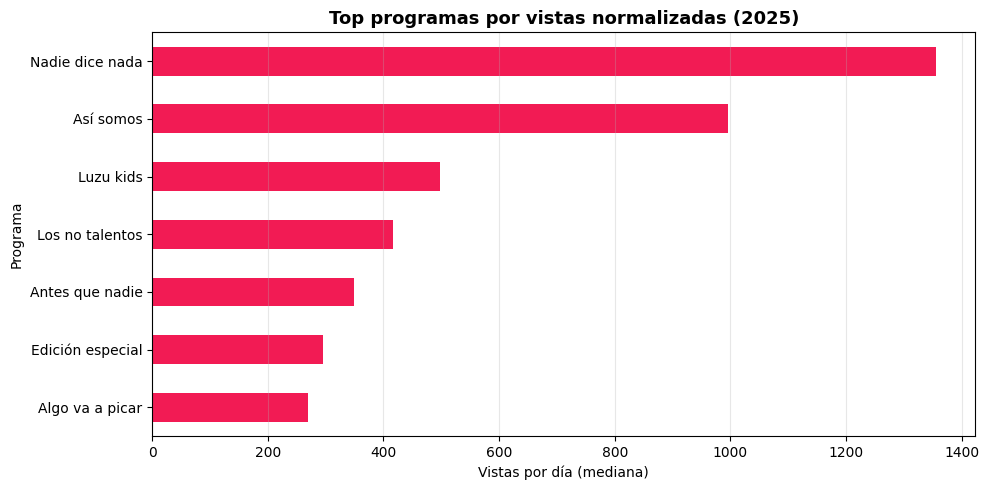

In [21]:
import matplotlib.pyplot as plt

# Mediana de vistas normalizadas por programa (2025)
ranking_2025 = (
    df_luzu_2025_core
    .groupby('Programs')['Views_per_day']
    .median()
    .sort_values(ascending=True)
    .tail(7) #Top 7
)

plt.figure(figsize=(10, 5))

ranking_2025.plot(
    kind='barh',
    color=luzu_palette['magenta']
)

plt.title(
    'Top programas por vistas normalizadas (2025)',
    fontsize=13,
    weight='bold'
)
plt.xlabel('Vistas por día (mediana)')
plt.ylabel('Programa')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Comparativa interanual 2024-2025**

Para evaluar la evolución del rendimiento por programa, se realizó una comparación interanual (2024 vs 2025) considerando exclusivamente los programas presentes en ambos períodos, evitando sesgos derivados de altas o bajas en la grilla. La métrica utilizada fue la mediana de vistas normalizadas por día, lo que permite una comparación robusta entre programas con diferente volumen de contenido.

In [22]:
# 1. Obtención de programas comunes

programas_2024 = set(df_luzu_2024['Programs'].unique())
programas_2025 = set(df_luzu_2025_core['Programs'].unique())

programas_comunes = programas_2024.intersection(programas_2025)

# 2. Filtrar ambos DataFrames

df_2024_common = df_luzu_2024[
    df_luzu_2024['Programs'].isin(programas_comunes)
]

df_2025_common = df_luzu_2025_core[
    df_luzu_2025_core['Programs'].isin(programas_comunes)
]

# 3. Calcular la métrica a comparar

views_2024 = (
    df_2024_common
    .groupby('Programs')['Views_per_day']
    .median()
    .reset_index(name='views_2024')
)

views_2025 = (
    df_2025_common
    .groupby('Programs')['Views_per_day']
    .median()
    .reset_index(name='views_2025')
)

# 4. Unir para comparar

comparison = views_2024.merge(views_2025, on='Programs')

In [23]:
# Verificación views 2024
views_2024

,Programs,views_2024
0,Algo de música,9.249717
1,Antes que nadie,133.185321
2,Así somos,226.405634
3,Edición especial,30.195876
4,El reality de Nadie dice nada,128.421627
5,FM Luzu,10.690377
6,Luzu FC,124.877960
7,Nada que no sepamos,13.294424
8,Nadie dice nada,417.807453
9,Patria y familia,97.370748


In [24]:
# Verificación views 2025
views_2025

,Programs,views_2025
0,Algo de música,71.491610
1,Antes que nadie,348.428936
2,Así somos,996.125000
3,Edición especial,295.818182
4,El reality de Nadie dice nada,143.272884
5,FM Luzu,46.663194
6,Luzu FC,230.860215
7,Nada que no sepamos,13.742297
8,Nadie dice nada,1355.757533
9,Patria y familia,216.014245


In [25]:
# Se instala la librería adjustText para ajustar automáticamente la posición de textos en el gráfico y evitar solapamientos

!pip install adjustText


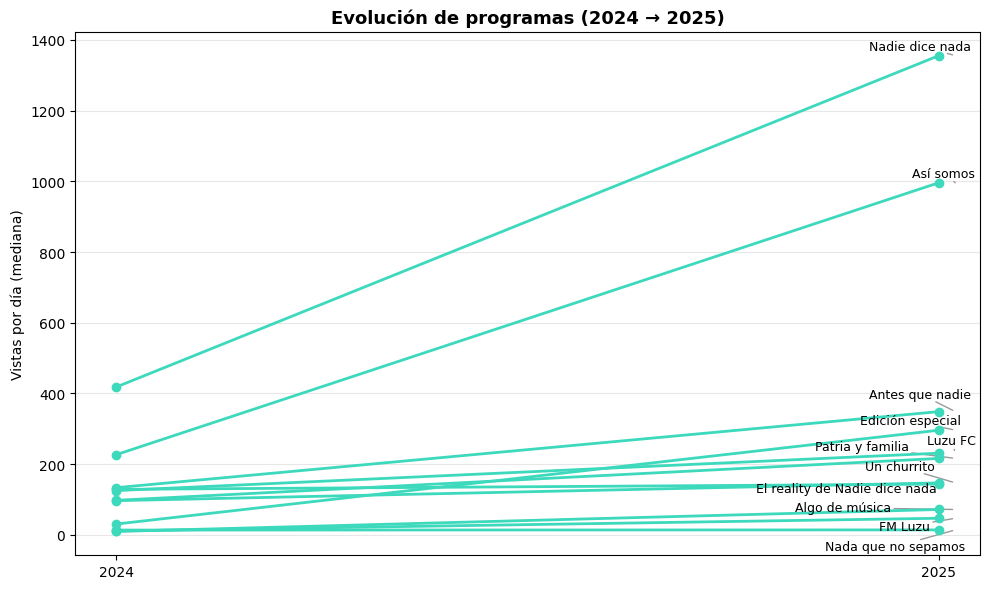

In [26]:
from adjustText import adjust_text

# Ordenar por 2025 reduce el solapamiento

comparison_sorted = comparison.sort_values('views_2025')

texts = []

plt.figure(figsize=(10, 6))

for row in comparison_sorted.itertuples():
    color = (
        luzu_palette['turquoise']
        if row.views_2025 >= row.views_2024 # Si el programa creció en 2025 → color turquesa
        else luzu_palette['magenta'] # Si cayó → color magenta
    )

    plt.plot(
        ['2024', '2025'],
        [row.views_2024, row.views_2025],
        marker='o',
        color=color,
        linewidth=2
    )

    texts.append(
        plt.text(1.02, row.views_2025, row.Programs, fontsize=9)
    )

adjust_text(texts, arrowprops=dict(arrowstyle='-', alpha=0.4))

plt.title('Evolución de programas (2024 → 2025)', fontsize=13, weight='bold')
plt.ylabel('Vistas por día (mediana)')
plt.xticks([0, 1], ['2024', '2025'])
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


**Porcentaje de variación interanual**

In [27]:
comparison['pct_change_views'] = (
    (comparison['views_2025'] - comparison['views_2024'])
    / comparison['views_2024']
) * 100

comparison['pct_change_views'] = comparison['pct_change_views'].round(1)

In [28]:
comparison.sort_values('pct_change_views', ascending= False)

,Programs,views_2024,views_2025,pct_change_views
3,Edición especial,30.195876,295.818182,879.7
0,Algo de música,9.249717,71.491610,672.9
2,Así somos,226.405634,996.125000,340.0
5,FM Luzu,10.690377,46.663194,336.5
8,Nadie dice nada,417.807453,1355.757533,224.5
1,Antes que nadie,133.185321,348.428936,161.6
9,Patria y familia,97.370748,216.014245,121.8
6,Luzu FC,124.877960,230.860215,84.9
10,Un churrito,96.425895,146.838926,52.3
4,El reality de Nadie dice nada,128.421627,143.272884,11.6


Si bien el programa "Nadie dice nada" lidera en vistas normalizadas en 2025, el programa "Edición especial" presenta el mayor crecimiento interanual (+879,7%), lo que indica una aceleración reciente en la tracción de audiencia.

No obstante, el recuento de visualizaciones de los programas subidos a la plataforma de YouTube registra un cambio de modalidad desde el año 2024 al 2025. Por este motivo el porcentaje no es tenido en cuenta como hallazgo, aunque sí la tendencia interanual de crecimiento.

1.b ¿Cuáles crecen más rápido tras publicarse?

In [29]:
# Se analiza una ventana temporal corta de 7 días para evaluar un impacto inmediato.

df_fast = df_luzu_2025_core[
    df_luzu_2025_core['Days_since_published'] <= 7
]

In [30]:
growth_by_program = (
    df_fast
    .groupby('Programs')['Growth_factor']
    .median()
    .sort_values(ascending=True)
)
growth_by_program

,Growth_factor
Programs,
Algo de música,477.875594
Los no talentos,567.857668
La novela,830.138175
Se fue larga,1296.635778
Edición especial,1539.355609
Patria y familia,1630.214536
Algo va a picar,4700.781342
Antes que nadie,8911.046369
Nadie dice nada,16154.818170


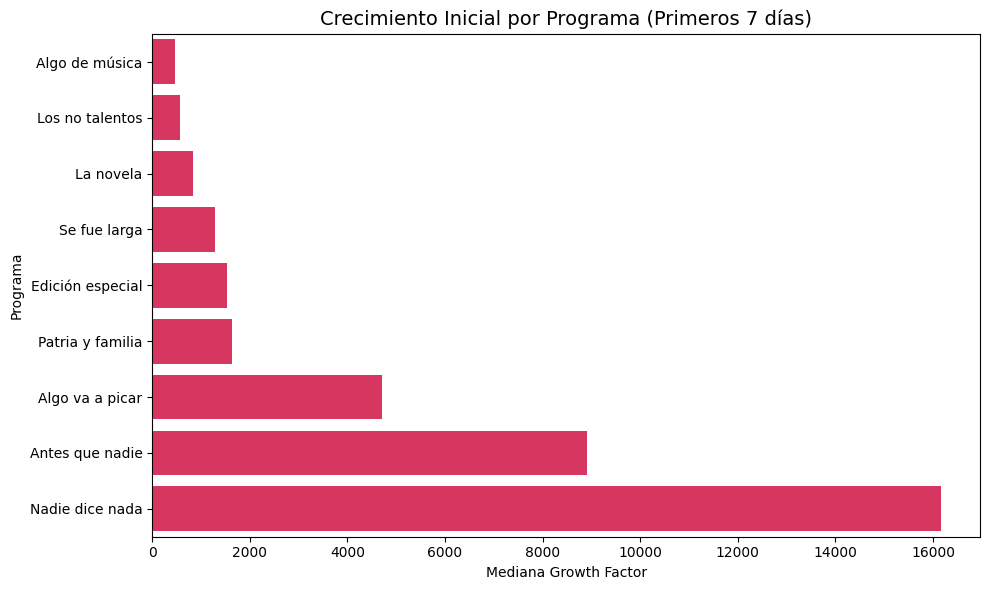

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.barplot(
    x=growth_by_program.values,
    y=growth_by_program.index,
    color='#F21B54',
    orient='h'
)

plt.title('Crecimiento Inicial por Programa (Primeros 7 días)', fontsize=14)
plt.xlabel('Mediana Growth Factor')
plt.ylabel('Programa')
plt.tight_layout()
plt.show()


In [32]:
# Scatter velocidad vs volumen

comparison_growth = (
    df_fast
    .groupby('Programs')
    .agg({
        'Growth_factor': 'median',
        'Views_per_day': 'median'
    })
    .reset_index()
)
comparison_growth

,Programs,Growth_factor,Views_per_day
0,Algo de música,477.875594,10379.500000
1,Algo va a picar,4700.781342,25142.000000
2,Antes que nadie,8911.046369,65180.428571
3,Edición especial,1539.355609,8761.000000
4,La novela,830.138175,12094.166667
5,Los no talentos,567.857668,5064.000000
6,Nadie dice nada,16154.818170,164972.571429
7,Patria y familia,1630.214536,25425.511905
8,Se fue larga,1296.635778,20099.107143


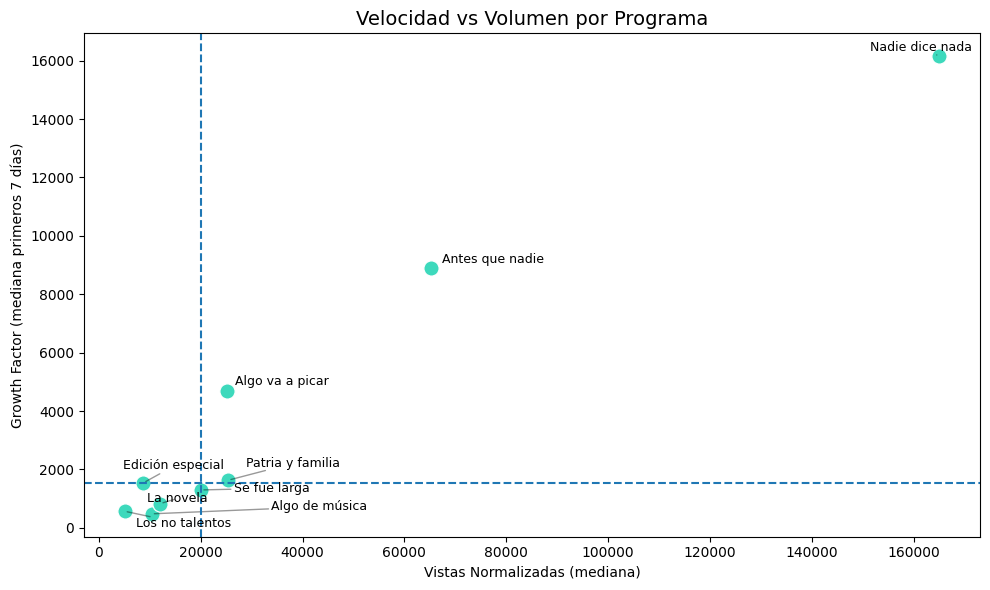

In [76]:
plt.figure(figsize=(10, 6))

from adjustText import adjust_text

# Cálculo de medianas para los cuadrantes
x_med = comparison_growth['Views_per_day'].median()
y_med = comparison_growth['Growth_factor'].median()

# Scatter base
sns.scatterplot(
    data=comparison_growth,
    x='Views_per_day',
    y='Growth_factor',
    color='#3DD9BC',
    s=120
)

# Líneas de cuadrantes
plt.axvline(x_med, linestyle="--")
plt.axhline(y_med, linestyle="--")

# ETIQUETAS SIN SUPERPOSICIÓN
# Crear lista de textos
texts = []

for row in comparison_growth.itertuples():
    texts.append(
        plt.text(
            row.Views_per_day,
            row.Growth_factor,
            row.Programs,
            fontsize=9
        )
    )

# Ajustar automáticamente posiciones
adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", alpha=0.4)
)

plt.title('Velocidad vs Volumen por Programa', fontsize=14)
plt.xlabel('Vistas Normalizadas (mediana)')
plt.ylabel('Growth Factor (mediana primeros 7 días)')

plt.tight_layout()
plt.show()


###**Insights 1**

1. Líder estructural: **Nadie Dice Nada**

Evidencia:

Primero en el Ranking 2025

Mayor crecimiento inicial (primeros 7 días)

Cuadrante superior derecho (alto volumen + alta velocidad)

Insight:

Es el motor principal del ecosistema.
No solo tiene volumen, sino capacidad consistente de activar audiencia rápidamente.

Implicancia negocio:

Mantener inversión prioritaria

Usarlo como “tractor” para cross-promoción

Es benchmark interno

2. Programas con tracción fuerte y sostenible:
**Antes que Nadie**
 y **Algo va a picar**

Evidencia:

Top 3 en crecimiento inicial

Cuadrante superior derecho

Insight:

Son programas con alta capacidad de activación temprana, aunque no lideren el ranking total.

Implicancia negocio:

Alto potencial de escalabilidad

Buenos candidatos para expansión de formato

Oportunidad de monetización adicional


**RESUMEN**

La tracción real está concentrada principalmente en Nadie Dice Nada, que combina liderazgo en volumen con aceleración inicial consistente.
Programas como Antes que Nadie y Algo va a picar muestran alta capacidad de activación temprana, posicionándose como pilares estratégicos secundarios.
Mientras tanto, algunos programas presentan crecimiento porcentual elevado pero aún no consolidan volumen estructural, lo que indica oportunidades de incubación más que liderazgo actual.

##**Necesidad del negocio 2**

**Pregunta 2**: ¿El formato del video influye en el rendimiento?

📌 Necesidad del negocio

Optimizar la grilla de contenidos: ¿conviene hacer programas completos, clips o highlights?

🔎 Preguntas clave

2.a ¿Qué formato genera más vistas por minuto?

2.b ¿Qué formato tiene mejor tasa de interacción?

In [34]:
# 2.a ¿Qué formato genera más vistas por minuto?

format_efficiency = (
    df_luzu_2025_core
    .groupby('Video_format')['Views_per_min_norm']
    .median()
    .sort_values(ascending=False)
)
format_efficiency

,Views_per_min_norm
Video_format,
Complete programming,305.849529
Short,204.147465
Clip,71.212132
Segmento,40.111004
Full program,9.668984


In [35]:
# Se detectan dos videos de Nadie Dice Nada con duración > 180 min y < 200 min, por lo que fueron clasificados como Complete programming
# Programa 2025-11-28 y 2025-10-16 , ambos son Full program
df_complete_programming = df_luzu_2025_core[df_luzu_2025_core['Video_format']=='Complete programming']
df_complete_programming

,Title,Published At,Views,Likes,Comments,Title_norm,Duration_min,Days_since_published,Views_per_day,Views_per_min_norm,Like_ratio,Comments_ratio,Engagement_rate,Growth_factor,Outlier_views,Outlier_likes,Outlier_engagement,Programs,Video_format
349,#NADIEDICENADA | DÍA HISTÓRICO: ROSALÍA QUE MU...,2025-11-28 16:47:00,2620959,96866,3241,#nadiedicenada | dia historico: rosalia que mu...,190.98,27,97072.555556,508.286499,0.036958,0.001237,0.038195,30042.273724,True,True,False,Nadie dice nada,Complete programming
981,#NADIEDICENADA | ¿RAUW ALEJANDRO DESAFÍA A LA ...,2025-10-16 16:51:19,1445387,40113,753,#nadiedicenada | ¿rauw alejandro desafia a la ...,199.67,70,20648.385714,103.412559,0.027752,0.000521,0.028273,9586.926811,True,True,False,Nadie dice nada,Complete programming


Debido a que los datos detectados influyen en los análisis relacionados a Video_format, se decide aplicar la función "clasificar formatos" para corregir la inconsistencia.



In [36]:
# Función para clasificar formato (Modificada según lo detectado en punto 2)
def clasificar_formato(duration):
    if duration <= 1:
        return 'Short'
    elif duration <= 10:
        return 'Clip'
    elif duration <= 30:
        return 'Segmento'
    elif duration <= 200 : # Se aumenta el tiempo de duración del programa completo
        return 'Full program'
    else:
        return 'Complete programming'

In [37]:
# Aplicación de la función Clasificar programa en la columna existente
df_luzu_2025_core.loc[:,'Video_format'] = df_luzu_2025_core['Duration_min'].apply(clasificar_formato)

In [38]:
# 2.a Se verifica la modificación anterior: ¿Qué formato genera más vistas por minuto?

format_efficiency = (
    df_luzu_2025_core
    .groupby('Video_format')['Views_per_min_norm']
    .median()
    .sort_values(ascending=False)
)
format_efficiency

,Views_per_min_norm
Video_format,
Short,204.147465
Clip,71.212132
Segmento,40.111004
Full program,9.678677


In [39]:
# 2.a Análisis adicional de volumen de visualizaciones vs eficiencia por minuto
format_summary = (
    df_luzu_2025_core
    .groupby('Video_format')
    .agg({
        'Views_per_day': 'median',
        'Views_per_min_norm': 'median'
    })
    .reset_index()
)
format_summary

,Video_format,Views_per_day,Views_per_min_norm
0,Clip,117.925817,71.212132
1,Full program,1097.853659,9.678677
2,Segmento,625.833333,40.111004
3,Short,130.251185,204.147465


###**Visualización 2**

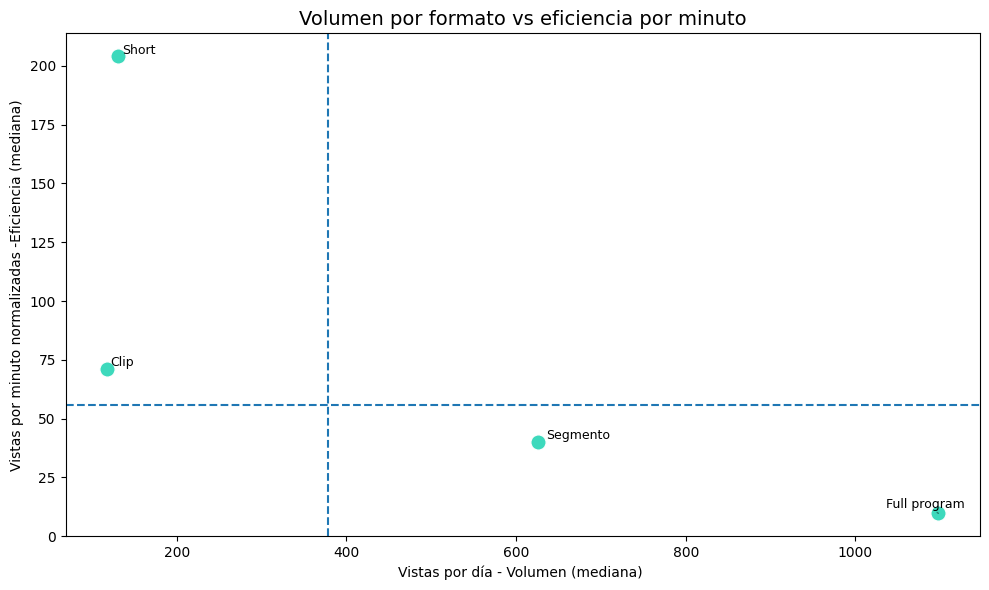

In [40]:
# Scatter: Volumen de visualizaciones vs eficiencia por minuto

plt.figure(figsize=(10, 6))

# Cálculo de medianas para los cuadrantes
x_med = format_summary['Views_per_day'].median()
y_med = format_summary['Views_per_min_norm'].median()

# Scatter base
sns.scatterplot(
    data=format_summary,
    x='Views_per_day',
    y='Views_per_min_norm',
    color='#3DD9BC',
    s=120
)

# Líneas de cuadrantes
plt.axvline(x_med, linestyle="--")
plt.axhline(y_med, linestyle="--")

# ETIQUETAS SIN SUPERPOSICIÓN
# Crear lista de textos
texts = []

for row in format_summary.itertuples():
    texts.append(
        plt.text(
            row.Views_per_day,
            row.Views_per_min_norm,
            row.Video_format,
            fontsize=9
        )
    )

# Ajustar automáticamente posiciones
adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", alpha=0.4)
)

plt.title('Volumen por formato vs eficiencia por minuto', fontsize=14)
plt.xlabel('Vistas por día - Volumen (mediana) ')
plt.ylabel('Vistas por minuto normalizadas -Eficiencia (mediana)')

plt.tight_layout()
plt.show()


In [41]:
# 2.b ¿Qué formato tiene mejor tasa de interacción?
format_engagement = (
    df_luzu_2025_core
    .groupby('Video_format')['Engagement_rate']
    .median()
    .sort_values(ascending=False)
)
format_engagement

,Engagement_rate
Video_format,
Segmento,0.047627
Full program,0.037891
Clip,0.031926
Short,0.023710


In [42]:
# 2.b Análisis adicional de eficiencia vs engagement
format_summary_eng = (
    df_luzu_2025_core
    .groupby('Video_format')
    .agg({
        'Engagement_rate': 'median',
        'Views_per_min_norm': 'median'
    })
    .reset_index()
)
format_summary_eng


,Video_format,Engagement_rate,Views_per_min_norm
0,Clip,0.031926,71.212132
1,Full program,0.037891,9.678677
2,Segmento,0.047627,40.111004
3,Short,0.023710,204.147465


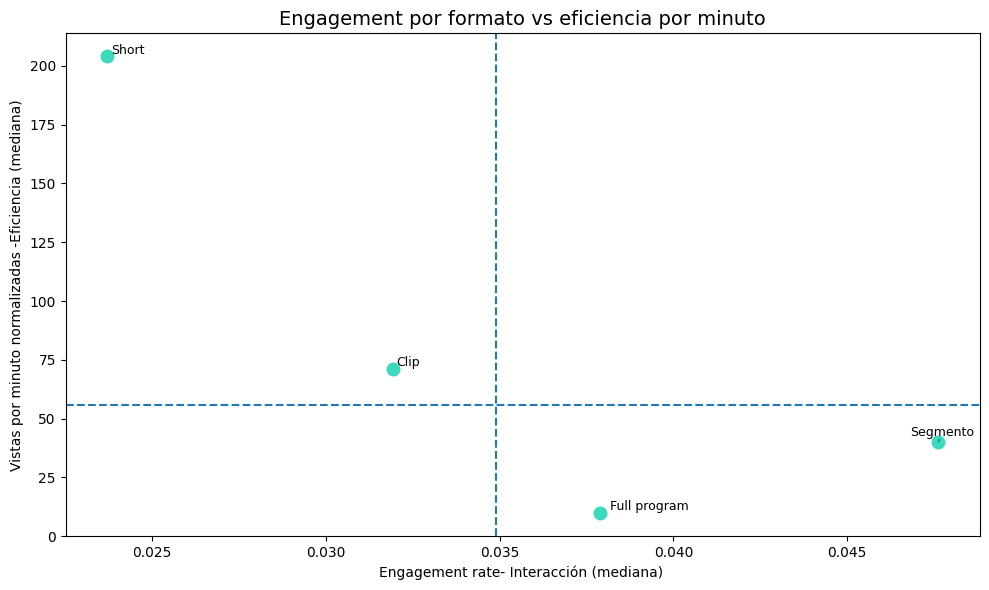

In [43]:
# Scatter: Engagement vs eficiencia por minuto

plt.figure(figsize=(10, 6))

# Cálculo de medianas para los cuadrantes
x_med = format_summary_eng['Engagement_rate'].median()
y_med = format_summary_eng['Views_per_min_norm'].median()

# Scatter base
sns.scatterplot(
    data=format_summary_eng,
    x='Engagement_rate',
    y='Views_per_min_norm',
    color='#3DD9BC',
    s=120
)

# Líneas de cuadrantes
plt.axvline(x_med, linestyle="--")
plt.axhline(y_med, linestyle="--")

# ETIQUETAS SIN SUPERPOSICIÓN
# Crear lista de textos
texts = []

for row in format_summary_eng.itertuples():
    texts.append(
        plt.text(
            row.Engagement_rate,
            row.Views_per_min_norm,
            row.Video_format,
            fontsize=9
        )
    )

# Ajustar automáticamente posiciones
adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", alpha=0.4)
)

plt.title('Engagement por formato vs eficiencia por minuto', fontsize=14)
plt.xlabel('Engagement rate- Interacción (mediana) ')
plt.ylabel('Vistas por minuto normalizadas -Eficiencia (mediana)')

plt.tight_layout()
plt.show()

Aunque los clips captan atención rápida, los programas largos generan mayor compromiso proporcional,
indicando audiencia más profunda y fidelizada

###**Insights 2**

El formato influye significativamente en el rendimiento, pero no de forma unidimensional. Los formatos cortos (short y clip) destacan en eficiencia de consumo, actuando como herramientas de captación. En contraste, los segmentos y programas completos presentan mayores tasas de interacción proporcional, indicando mayor profundidad de engagement. Esto sugiere que la optimización de la grilla no debe orientarse a sustituir formatos, sino a diseñar un ecosistema donde los contenidos cortos atraigan audiencia y los formatos largos consoliden comunidad.

##**Necesidad del negocio 3**

**Pregunta 3:** ¿Qué tan comprometida está la audiencia (más allá de las vistas)?

📌 Necesidad del negocio
Las vistas no lo son todo: sponsors y marcas miran engagement real.

🔎 Preguntas clave

3.a ¿Qué videos generan más likes por vista?

3.b ¿Qué programas generan conversación?

3.c ¿Dónde la audiencia participa activamente?

In [45]:
# 3.a ¿Qué videos generan más likes por vista?

# 1. Se filtran videos con más de 1000 likes para evitar un ratio engañoso
df_filtrado = df_luzu_2025[df_luzu_2025['Views'] > 1000]

# 2. Ranking de videos
top_videos = (
    df_filtrado
    .sort_values('Like_ratio', ascending=False)
    .head(15)
)
top_videos

,Title,Published At,Views,Likes,Comments,Title_norm,Duration_min,Days_since_published,Views_per_day,Views_per_min_norm,Like_ratio,Comments_ratio,Engagement_rate,Growth_factor,Outlier_views,Outlier_likes,Outlier_engagement,Programs,Video_format
3051,GuidoCo nos odia?? #fmluzu #luzutv #crisvanadia,2025-05-19 10:14:13,179314,20428,14,guidoco nos odia?? #fmluzu #luzutv #crisvanadia,0.78,221,811.375566,1040.225084,0.113923,0.000078,0.114001,3783.679564,False,True,True,FM Luzu,Short
3615,El show debe continuar😂 Sin luz pero con toda ...,2025-03-20 21:06:16,13470,1487,18,el show debe continuar😂 sin luz pero con toda ...,1.27,280,48.107143,37.879640,0.110393,0.001336,0.111730,266.921839,False,False,True,FM Luzu,Clip
3346,Gustos que causas sustos😂🥲 que comen los madru...,2025-04-28 01:21:51,11391,1222,2,gustos que causas sustos😂🥲 que comen los madru...,0.88,242,47.070248,53.488918,0.107278,0.000176,0.107453,222.826563,False,False,True,FM Luzu,Short
3993,"#MAÑANASNOSTALGICAS | EL AMOR ESTÁ EN EL AIRE,...",2025-01-06 11:56:10,21140,2137,87,"#mananasnostalgicas | el amor esta en el aire,...",44.97,354,59.717514,1.327941,0.101088,0.004115,0.105203,378.738997,False,False,True,Mañanas nostálgicas,Full program
1877,#SEFUELARGA l JOCHE Y MIKI TIENEN CASAMIENTO G...,2025-08-08 19:42:30,128588,12975,145,#sefuelarga l joche y miki tienen casamiento g...,117.08,139,925.093525,7.901380,0.100904,0.001128,0.102031,2654.987730,False,True,True,Se fue larga,Full program
2508,Mamaaaa el aguaaaa #fmluzu #luzutv #crisvanadia,2025-06-23 01:19:00,5602,565,2,mamaaaa el aguaaaa #fmluzu #luzutv #crisvanadia,1.92,186,30.118280,15.686604,0.100857,0.000357,0.101214,108.390026,False,False,True,FM Luzu,Clip
2235,Se viene AQN infantil 🫶🏻 #aqn #antesquenadie #...,2025-07-15 11:11:14,3898,391,0,se viene aqn infantil 🫶🏻 #aqn #antesquenadie #...,3.02,164,23.768293,7.870296,0.100308,0.000000,0.100308,76.577394,False,False,True,Antes que nadie,Clip
2921,Uganda fan de Messi? OBVIO que si 🩷 #messi #nd...,2025-05-24 14:03:02,83338,8345,17,uganda fan de messi? obvio que si 🩷 #messi #nd...,2.00,216,385.824074,192.912037,0.100134,0.000204,0.100338,1554.304748,False,True,True,Nadie dice nada,Clip
3791,#LANOVELA l EL VIDEOCLIP DE LA TOTONA. LO MEJO...,2025-02-06 00:02:15,112575,11224,614,#lanovela l el videoclip de la totona. lo mejo...,1.68,323,348.529412,207.457983,0.099702,0.005454,0.105157,2047.833461,False,True,True,La novela,Clip
1907,#SEFUELARGA l SECRETOS DE LOS CONDUCTORES Y YA...,2025-08-06 19:43:59,126802,12524,150,#sefuelarga l secretos de los conductores y ya...,119.65,141,899.304965,7.516130,0.098768,0.001183,0.099951,2557.393519,False,True,True,Se fue larga,Full program


El patrón detectado de los videos con mayor Like_ratio es contenido breve, emocional y altamente identificable, con fuerte componente musical o humorístico, que activa respuesta afectiva inmediata.

Análisis adicional:
En el punto 2 confirmamos que el formato Short tiene alta eficiencia pero bajo engagement_rate comparado con Segmento. Aquí verificamos que dentro de los Short hay subtipos que disparan muchísimo el like, por lo tanto no todos los shorts convierten igual.

In [46]:
# 3.b ¿Qué programas generan conversación?

top_comment = (
    df_luzu_2025_core # Se considera el df 2025 con programas regulares.
    .groupby('Programs')
    .agg({
        'Comments_ratio': 'median',
        'Comments': 'median',
        'Views_per_day': 'median'
    })
    .sort_values('Comments', ascending=False)
    .reset_index()
)
top_comment

,Programs,Comments_ratio,Comments,Views_per_day
0,Luzu FC,0.006707,432.0,230.860215
1,Un churrito,0.003002,157.0,146.838926
2,Así somos,0.001020,55.0,996.125000
3,La novela,0.000967,50.0,265.006042
4,Nadie dice nada,0.000430,34.0,1355.757533
5,Luzu kids,0.000965,25.0,498.187500
6,El reality de Nadie dice nada,0.000287,23.5,143.272884
7,Antes que nadie,0.000380,19.0,348.428936
8,Se fue larga,0.000438,13.0,230.219098
9,Patria y familia,0.000326,8.0,216.014245


###**Visualización 3**

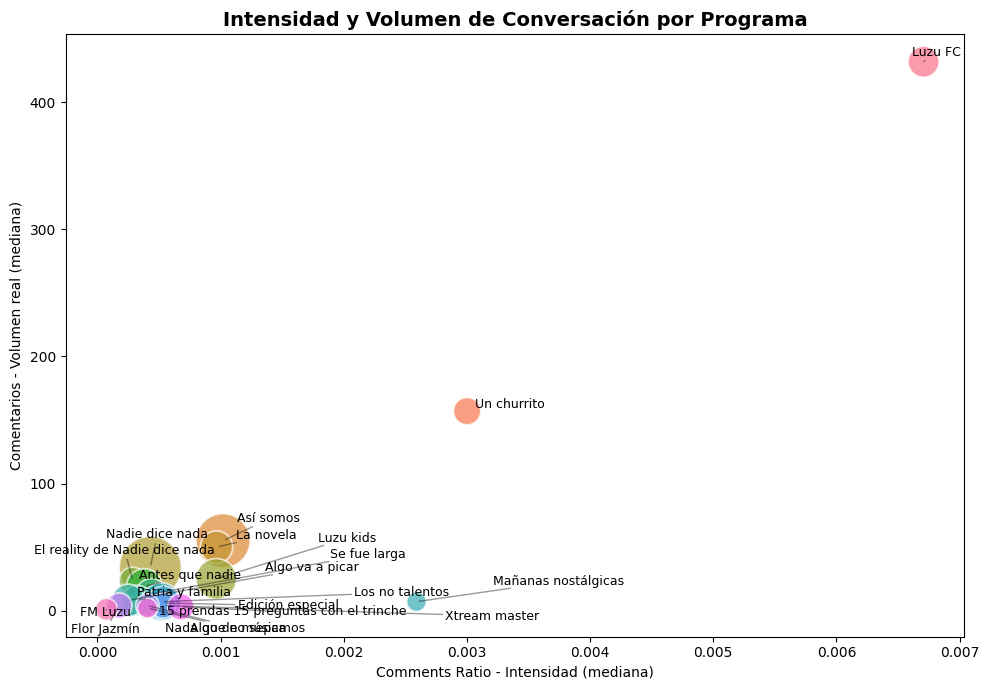

In [47]:
# Gráfico bubble chart

plt.figure(figsize=(10, 7))

ax = sns.scatterplot(
    data=top_comment,
    x='Comments_ratio', #Intensidad de comentarios
    y='Comments', #Volumen real de comentarios
    size='Views_per_day', # Escala de audiencia
    hue='Programs',
    sizes=(200, 2000),
    alpha=0.7,
    legend=False
)

# Etiquetas
texts = []

for i in range(top_comment.shape[0]):
    texts.append(
        plt.text(
            top_comment['Comments_ratio'][i],
            top_comment['Comments'][i],
            top_comment['Programs'][i],
            fontsize=9
        )
    )

adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", alpha=0.4)
    )

plt.title('Intensidad y Volumen de Conversación por Programa',
          fontsize=14, weight='bold')
plt.xlabel('Comments Ratio - Intensidad (mediana)')
plt.ylabel('Comentarios - Volumen real (mediana)')

plt.tight_layout()
plt.show()


El gráfico anterior parece indicar que la mayoría de los programas generan conversación limitada tanto en intensidad como en volumen. No obstante, los dos programas ganadores no fueron programas anuales, fueron temporadas cortas (2–3 semanas) funcionando más como eventos especiales.

In [48]:
# Filtro de los programas especiales del 2025

df_luzu_2025_core_b = df_luzu_2025_core[
    ~df_luzu_2025_core['Programs'].isin([
        'Luzu FC',
        'Un churrito'
    ])
]

# Recálculo del df sin programas especiales
top_comment_core = (
    df_luzu_2025_core_b
    .groupby('Programs')
    .agg({
        'Comments_ratio': 'median',
        'Comments': 'median',
        'Views_per_day': 'median'
    })
    .sort_values('Comments', ascending=False)
    .reset_index()
)
top_comment_core

,Programs,Comments_ratio,Comments,Views_per_day
0,Así somos,0.001020,55.0,996.125000
1,La novela,0.000967,50.0,265.006042
2,Nadie dice nada,0.000430,34.0,1355.757533
3,Luzu kids,0.000965,25.0,498.187500
4,El reality de Nadie dice nada,0.000287,23.5,143.272884
5,Antes que nadie,0.000380,19.0,348.428936
6,Se fue larga,0.000438,13.0,230.219098
7,Algo va a picar,0.000251,8.0,268.882658
8,Patria y familia,0.000326,8.0,216.014245
9,Los no talentos,0.000520,7.0,417.113821


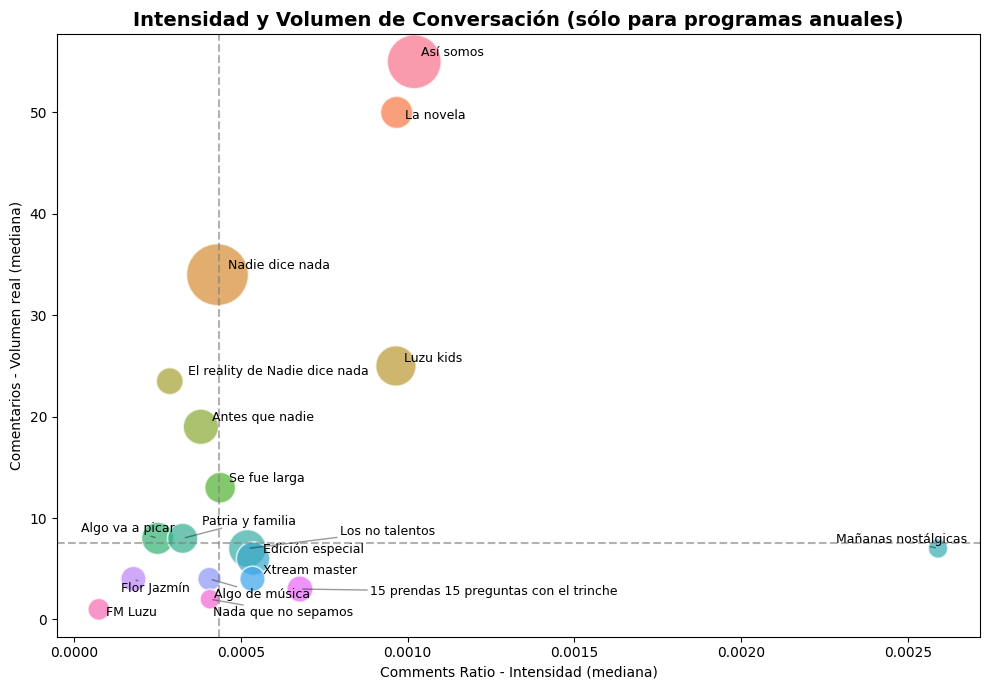

In [49]:
# Gráfico bubble chart sin programas eventos especiales

plt.figure(figsize=(10, 7))

ax = sns.scatterplot(
    data=top_comment_core,
    x='Comments_ratio', #Intensidad de comentarios
    y='Comments', #Volumen real de comentarios
    size='Views_per_day', # Escala de audiencia
    hue='Programs',
    sizes=(200, 2000),
    alpha=0.7,
    legend=False
)

# Etiquetas
texts = []

for i in range(top_comment_core.shape[0]):
    texts.append(
        plt.text(
            top_comment_core['Comments_ratio'][i],
            top_comment_core['Comments'][i],
            top_comment_core['Programs'][i],
            fontsize=9
        )
    )

adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", alpha=0.4)
    )

# Líneas de cuadrantes
x_median = top_comment_core['Comments_ratio'].median()
y_median = top_comment_core['Comments'].median()

plt.axvline(x=x_median, linestyle="--", color="gray", alpha=0.6)
plt.axhline(y=y_median, linestyle="--", color="gray", alpha=0.6)

plt.title('Intensidad y Volumen de Conversación (sólo para programas anuales)',
          fontsize=14, weight='bold')
plt.xlabel('Comments Ratio - Intensidad (mediana)')
plt.ylabel('Comentarios - Volumen real (mediana)')

plt.tight_layout()
plt.show()

In [77]:
# 3.c ¿Dónde la audiencia participa activamente?
'''La combinación de programa + formato corresponde al mapa real de participación,
mientras que Comments Ratio es el indicador más fuerte de participación activa.'''

# Participación por programa y formato
participacion_comb = (
    df_luzu_2025_core
    .groupby(['Programs','Video_format'])
    .agg({
        'Comments_ratio': 'median'
    })
    .sort_values('Comments_ratio', ascending=True)
    .reset_index()
)
participacion_comb


,Programs,Video_format,Comments_ratio
0,FM Luzu,Short,0.000043
1,Algo de música,Short,0.000087
2,Algo va a picar,Short,0.000142
3,FM Luzu,Clip,0.000150
4,La novela,Short,0.000172
5,Algo va a picar,Clip,0.000172
6,Flor Jazmín,Clip,0.000178
7,Antes que nadie,Clip,0.000179
8,Xtream master,Short,0.000187
9,Patria y familia,Clip,0.000189


En el Top 10:

6 de 10 son Full program

4 de 10 son Segmento

Ningún Short aparece en el top

Eso sugiere que la participación activa (comentarios proporcionales) se concentra en formatos largos, no en clips cortos

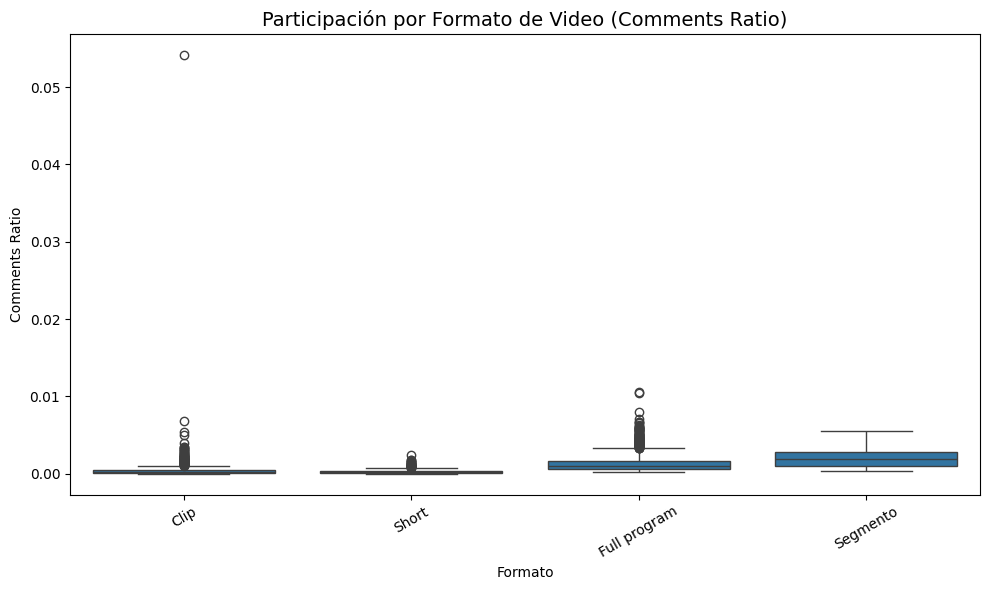

In [52]:
# PASO 1 — ¿En qué formato participa más la audiencia?

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_luzu_2025_core,
    x='Video_format',
    y='Comments_ratio'
)

plt.title('Participación por Formato de Video (Comments Ratio)', fontsize=14)
plt.xlabel('Formato')
plt.ylabel('Comments Ratio')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()



Se detecta un valor extremo en formato Clip que distorsiona la distribución general. Se realiza un análisis adicional excluyendo el outlier para evaluar el comportamiento estructural del resto del contenido.

In [53]:
# Identificación de la fila exacta sin el outlier

outlier_value = (
    df_luzu_2025_core
    .loc[df_luzu_2025_core['Video_format'] == 'Clip', 'Comments_ratio']
    .max()
)

df_luzu_2025_core[df_luzu_2025_core['Comments_ratio'] == outlier_value]


,Title,Published At,Views,Likes,Comments,Title_norm,Duration_min,Days_since_published,Views_per_day,Views_per_min_norm,Like_ratio,Comments_ratio,Engagement_rate,Growth_factor,Outlier_views,Outlier_likes,Outlier_engagement,Programs,Video_format
3159,#FMLUZU | NOTA EXCLUSIVA A GOTTI,2025-05-13 11:13:01,6596,557,357,#fmluzu | nota exclusiva a gotti,9.2,227,29.057269,3.158399,0.084445,0.054124,0.138569,168.344412,False,False,True,FM Luzu,Clip


In [54]:
# Dataframe sin el outlier

df_luzu_2025_sin_outlier = df_luzu_2025_core[
    df_luzu_2025_core['Comments_ratio'] != outlier_value
].copy()


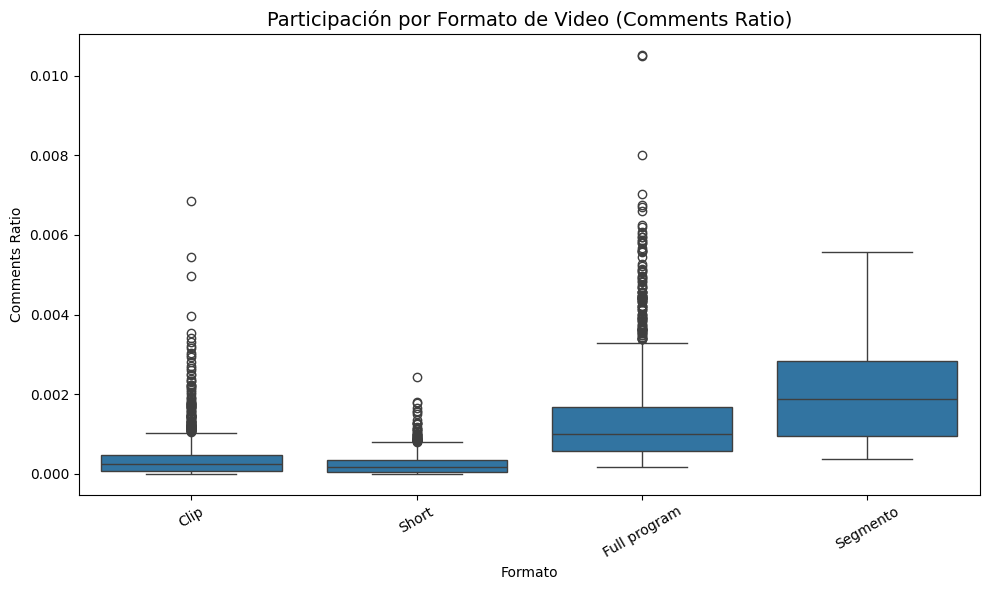

In [55]:
# Se repite el PASO 1 con el nuevo dataframe
# PASO 1 — ¿En qué formato participa más la audiencia?

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_luzu_2025_sin_outlier,
    x='Video_format',
    y='Comments_ratio'
)

plt.title('Participación por Formato de Video (Comments Ratio)', fontsize=14)
plt.xlabel('Formato')
plt.ylabel('Comments Ratio')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


La conversación estructural del canal se concentra en contenidos largos, no en formatos breves.

In [56]:
luzu_palette = {
    "Full program": "#F21B54",   # magenta
    "Segmento": "#5B2EFF",       # violeta
    "Clip": "#0D0C0D",           # black
    "Short": "#3DD9BC"           # turquesa
}

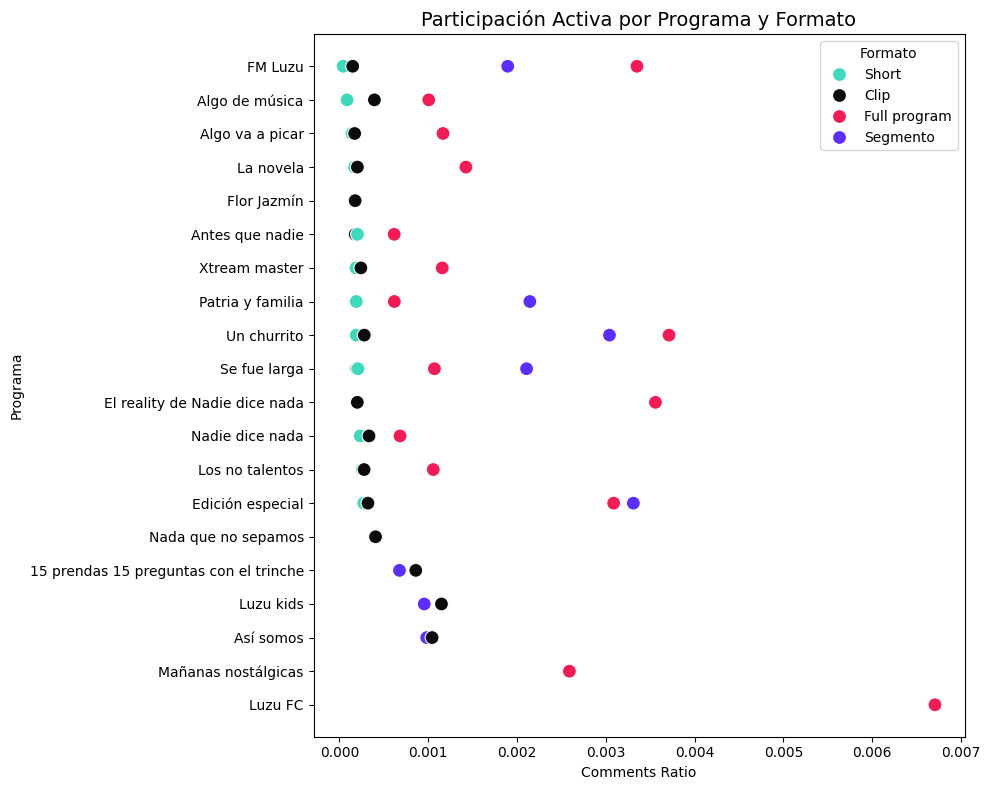

In [57]:
# PASO 2 — ¿En qué combinación Programa + Formato hay mayor participación activa?

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=participacion_comb,
    x='Comments_ratio',
    y='Programs',
    hue='Video_format',
    palette=luzu_palette,
    s=100
)

plt.title('Participación Activa por Programa y Formato', fontsize=14)
plt.xlabel('Comments Ratio')
plt.ylabel('Programa')

plt.legend(title='Formato', loc='upper right')
plt.tight_layout()
plt.show()


Insight:

Los programas completos son más estables, pero además concentran los niveles más altos de conversación cuando se activa la comunidad.

###**Insights 3**

Los videos con mayor tasa de likes por vista comparten una fuerte carga emocional y musical, en formato short. Predominan contenidos de identificación afectiva (confesiones, recuerdos, mensajes colectivos) y humor ligero, lo que sugiere que el like funciona como expresión de conexión emocional inmediata. El formato corto potencia esta dinámica al facilitar el consumo rápido y la compartibilidad en redes, amplificando el descubrimiento del canal.

La conversación estructural del canal se concentra en contenidos largos, no en formatos breves. Los segmentos presentan una mayor participación típica y mayor dispersión en el nivel de comentarios, lo que sugiere que actúan como piezas de contenido que estimulan conversación puntual y reactiva. En contraste, los programas completos muestran un comportamiento más estable en el tiempo, aunque ocasionalmente registran picos excepcionales de conversación, se consolidan como espacios contenedores de la comunidad.

Excluyendo los programas especiales de corta duración, se observa una distribución clara entre los programas estructurales del canal:

- Alto volumen de comentarios + alta intensidad de comentarios

    - Así Somos, La Novela, Nadie Dice Nada, Luzu Kids, Se Fue Larga

  Programas con comunidad consolidada y conversación masiva.

- Alto volumen de comentarios + menor intensidad proporcional de comentarios

    - El Reality de Nadie Dice Nada, Antes Que Nadie, Patria y Familia, Algo Va a Picar
  
  Gran audiencia con conversación más diluida proporcionalmente.

- Baja intensidad de comentarios + alto volumen de comentarios

    - Edición Especial, Los No Talentos, Mañanas Nostálgicas, Xtream Máster, 15 Prendas 15 Preguntas
    
    Consumo significativo, menor activación conversacional.

- Bajo volumen de comentarios + baja intensidad de comentarios

  - FM LUZU, Flor Jazmín, Algo de Música, Nada Que No Sepamos

  Menor movilización comunitaria.


##**Necesidad del negocio 4**

**Pregunta 4:** ¿Qué características tienen los contenidos que generan comportamientos extremos de audiencia?

📌 Necesidad del negocio

Identificar patrones asociados a picos excepcionales de visualización o engagement permite:

- Optimizar la planificación editorial

- Maximizar probabilidad de viralidad

- Diseñar contenidos replicables

- Aumentar el atractivo para sponsors

Para el análisis de viralidad se toman en cuenta las columnas *outlier* del df_luzu_2025_core. Debido a que estas contienen datos booleanos y pueden ser *outliers True* por encontrarse debajo del límite inferior, se realiza una comprobación para verificar si estos existen.

In [58]:
# Se comprueba que no existen outliers True para Views

q1 = df_luzu_2025_core['Views'].quantile(0.25)
q3 = df_luzu_2025_core['Views'].quantile(0.75)
iqr = q3 - q1
limite_inf = q1 - 1.5 * iqr

df_luzu_2025_core[
    df_luzu_2025_core['Outlier_views'] &
    (df_luzu_2025_core['Views'] < limite_inf)
]


,Title,Published At,Views,Likes,Comments,Title_norm,Duration_min,Days_since_published,Views_per_day,Views_per_min_norm,Like_ratio,Comments_ratio,Engagement_rate,Growth_factor,Outlier_views,Outlier_likes,Outlier_engagement,Programs,Video_format


In [59]:
# Se comprueba que no existen outliers True para Engagement_rate

q1 = df_luzu_2025_core['Engagement_rate'].quantile(0.25)
q3 = df_luzu_2025_core['Engagement_rate'].quantile(0.75)
iqr = q3 - q1
limite_inf = q1 - 1.5 * iqr

df_luzu_2025_core[
    df_luzu_2025_core['Outlier_engagement'] &
    (df_luzu_2025_core['Engagement_rate'] < limite_inf)
]


,Title,Published At,Views,Likes,Comments,Title_norm,Duration_min,Days_since_published,Views_per_day,Views_per_min_norm,Like_ratio,Comments_ratio,Engagement_rate,Growth_factor,Outlier_views,Outlier_likes,Outlier_engagement,Programs,Video_format


In [78]:
# Se crea una nueva variable binaria a fin de detectar comportamiento extraordinario

df_luzu_2025_core.loc[:,'Viral_flag'] = (
    df_luzu_2025['Outlier_views'] |
    df_luzu_2025['Outlier_engagement']
)

In [61]:
# Análisis de viralidad histórica por formato

df_luzu_2025_core.groupby('Video_format')['Viral_flag'].mean().sort_values(ascending=False)

,Viral_flag
Video_format,
Full program,0.335755
Short,0.072189
Segmento,0.060606
Clip,0.058962


In [62]:
# Análisis de viralidad histórica por programa

df_luzu_2025_core.groupby('Programs')['Viral_flag'].mean().sort_values(ascending=False)

,Viral_flag
Programs,
Mañanas nostálgicas,0.736842
Nadie dice nada,0.402887
Antes que nadie,0.291498
Edición especial,0.082192
Algo va a picar,0.059055
Los no talentos,0.054545
Luzu kids,0.052632
Patria y familia,0.048951
Se fue larga,0.048319


In [63]:
# Identificación de patrones temáticos que aumentan la probabilidad de viralidad

# 1. Palabras más frecuentes en virales

from collections import Counter
import re

text_virales = " ".join(df_luzu_2025_core[df_luzu_2025_core['Viral_flag']]['Title_norm'])
words_virales = re.findall(r'\b\w+\b', text_virales)

Counter(words_virales).most_common(20)


[('y', 431),
 ('de', 316),
 ('nadiedicenada', 305),
 ('la', 236),
 ('el', 220),
 ('luzutv', 152),
 ('antesquenadie', 143),
 ('en', 142),
 ('a', 121),
 ('con', 97),
 ('un', 78),
 ('se', 73),
 ('los', 73),
 ('que', 69),
 ('del', 67),
 ('ndn', 60),
 ('es', 53),
 ('momi', 50),
 ('nos', 47),
 ('vivo', 45)]

In [64]:
# 2. Palabras más frecuentes en no virales

text_no_virales = " ".join(df_luzu_2025_core[~df_luzu_2025_core['Viral_flag']]['Title_norm'])
words_no_virales = re.findall(r'\b\w+\b', text_no_virales)

Counter(words_no_virales).most_common(20)


[('luzutv', 2269),
 ('de', 1052),
 ('y', 1041),
 ('la', 829),
 ('el', 762),
 ('patriayfamilia', 680),
 ('l', 578),
 ('a', 533),
 ('nadiedicenada', 457),
 ('sefuelarga', 456),
 ('en', 399),
 ('antesquenadie', 351),
 ('con', 350),
 ('fmluzu', 341),
 ('crisvanadia', 304),
 ('que', 291),
 ('ndn', 283),
 ('se', 278),
 ('lanovela', 261),
 ('aqn', 252)]

Palabras que aparecen proporcionalmente más en virales que en no virales:
- Nadie dice nada
- Antes que Nadie
- Momi.

Con el objetivo de mejorar la detección de patrones temáticos se amplía el subconjunto de análisis a outliers de views, los que suelen ser más numerosos que los de engagement extremo.

In [79]:
# # 2 a. Palabras más frecuentes en virales (sólo ALCANCE extraordinario)

# Creación de una nueva variable
df_luzu_2025_core.loc[:,'High_reach_flag'] = df_luzu_2025_core['Outlier_views']

# Análisis del nuevo subconjunto
text_high_reach = " ".join(
    df_luzu_2025_core[df_luzu_2025_core['High_reach_flag']]['Title_norm']
)
words_high_reach = re.findall(r'\b\w+\b', text_high_reach)

Counter(words_high_reach).most_common(20)



[('y', 400),
 ('nadiedicenada', 299),
 ('de', 293),
 ('la', 218),
 ('el', 200),
 ('antesquenadie', 139),
 ('en', 133),
 ('luzutv', 119),
 ('a', 114),
 ('con', 89),
 ('los', 66),
 ('un', 66),
 ('se', 63),
 ('del', 61),
 ('que', 53),
 ('ndn', 53),
 ('momi', 50),
 ('es', 47),
 ('nos', 44),
 ('su', 44)]

Del análisis anterior se interpreta que la viralidad no depende del tema sino del ecosistema del programa viral: audiencia consolidada, comunidad activa, host carismático.

No obstante, se intenta una búsqueda más fina para detectar patrones que combinen dos palabras. Se aplica un análisis de bigramas sobre los títulos de videos con comportamiento extremo en views para identificar patrones semánticos recurrentes. Se utiliza un filtro mínimo de frecuencia para eliminar ruido y obtener combinaciones relevantes desde una perspectiva estratégica.

In [66]:
# 3. Búsqueda de patrones semánticos (bigramas)

from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2), min_df=2)
X = vectorizer.fit_transform(df_luzu_2025_core[df_luzu_2025_core['Outlier_views']]['Title_norm'])

sum_words = X.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
sorted(words_freq, key=lambda x: x[1], reverse=True)[:15]


[('nadiedicenada luzutv', np.int64(69)),
 ('ndn nadiedicenada', np.int64(47)),
 ('en vivo', np.int64(42)),
 ('de la', np.int64(37)),
 ('en la', np.int64(23)),
 ('en el', np.int64(20)),
 ('todo sobre', np.int64(20)),
 ('el amor', np.int64(16)),
 ('de los', np.int64(15)),
 ('la vuelta', np.int64(15)),
 ('nadiedicenada la', np.int64(14)),
 ('luzutv nadiedicenada', np.int64(13)),
 ('vuelta de', np.int64(11)),
 ('nadiedicenada momi', np.int64(11)),
 ('nadiedicenada el', np.int64(11))]

In [80]:
# 4. Convertir patrones semánticos en variables
'''Se excluyen para este punto los nombres de programas detectados como virales en análisis anteriores'''

df_luzu_2025_core.loc[:,'Tema_emocional'] = df_luzu_2025_core['Title_norm'].str.contains('la vuelta|el amor|vuelta de|todo sobre')
df_luzu_2025_core.loc[:,'Tema_host_momi'] = df_luzu_2025_core['Title_norm'].str.contains('momi|en vivo')


In [68]:
# 5. Cálculo del impacto relativo

# Probabilidad de comportamiento extremo para contenido emotivo
prob_base = df_luzu_2025_core['Viral_flag'].mean()
prob_emocional = df_luzu_2025_core[df_luzu_2025_core['Tema_emocional']]['Viral_flag'].mean()

lift_emocional = prob_emocional / prob_base

# Probabilidad de comportamiento extremo para contenido presentado por host "Momi"
prob_host_momi = df_luzu_2025_core[df_luzu_2025_core['Tema_host_momi']]['Viral_flag'].mean()

lift_host_momi = prob_host_momi / prob_base


In [69]:
lift_emocional

np.float64(3.6287406154171507)

In [70]:
lift_host_momi

np.float64(2.296091159946797)

Los contenidos emocionales presentan 3.6x mayor probabilidad de comportamiento extremo respecto al promedio del canal, mientras que los videos presentados por *Momi* presentan 2.3x mayor probabilidad de comportamiento extremo.

In [71]:
# 6 Duración
df_luzu_2025_core.groupby('Viral_flag')['Duration_min'].median()


,Duration_min
Viral_flag,
False,1.65
True,124.58


El análisis automático de bigramas no evidencia patrones adicionales significativos. Por ello, se realiza un análisis de casos extremos (Top 15 videos por views) para detectar posibles eventos de alto impacto no capturados por frecuencia léxica, identificando la presencia recurrente de invitados/artistas como posible catalizador de alcance.


In [72]:
top15 = df_luzu_2025_core.sort_values('Views', ascending=False).head(15)
top15[['Title_norm', 'Views']]

,Title_norm,Views
2210,el padre de mis hijos es mi ex #sefuelarga #lu...,3488812
2601,cazzu habla de su maternidad #patriayfamilia ...,3424753
2817,asi ￼se conquista a una mujer #sefuelarga #luzutv,3136245
1655,thiago sigue deseando a pestanela #patriayfam...,2670720
349,#nadiedicenada | dia historico: rosalia que mu...,2620959
67,#nadiedicenada | una propuesta de davo: ¿hay b...,1872030
956,¿cuantos novios tuvimos? #ndn #nadiedicenada #...,1811435
3971,ferbo: su propio enemigo #unchurrito #luzutv,1764961
2602,cazzu habla de bad bunny #patriayfamilia #luzutv,1693029
490,#nadiedicenada | todo sobre el antel arena y n...,1662608


In [81]:
# Nueva temática detectada: celebridades invitadas

artistas = [
    'cazzu', 'rosalia', 'lali', 'ke personajes',
    'flor pena', 'marley'
]

df_luzu_2025_core.loc[:,'Tema_celebridad'] = df_luzu_2025_core['Title_norm'].str.contains(
    '|'.join(artistas)
)


In [74]:
# Cálculo del impacto relativo

# Probabilidad de comportamiento extremo para contenido relacionado a celebridades
prob_base = df_luzu_2025_core['Viral_flag'].mean()
prob_celebridad = df_luzu_2025_core[df_luzu_2025_core['Tema_celebridad']]['Viral_flag'].mean()

lift_celebridad = prob_celebridad / prob_base
lift_celebridad

np.float64(2.3188352915419976)

Los eventos con figuras externas de alto reconocimiento funcionan como catalizadores de alcance masivo, diferenciándose de los patrones emocionales o estructurales detectados previamente.

Los contenidos que presentan celebridades muestran una probabilidad de comportamiento extremo 2.3 veces superior al promedio del canal.

###**Insight 4**

El comportamiento extremo de audiencia en 2025 no responde principalmente a un tema aislado, sino a una combinación de tres grandes factores estructurales: formato, ecosistema del programa y eventos catalizadores.

- Los contenidos largos —particularmente programas completos— presentan mayor probabilidad de comportamiento extremo. La viralidad no se asocia necesariamente a la brevedad, sino a la profundidad de consumo y al engagement acumulado dentro de comunidades consolidadas.

- Los programas con mayor comunidad consolidada, Nadie dice nada y Antes que nadie, lideran el ranking.

- Patrones recurrentes: emoción y carisma potencian extremos. La emocionalidad actúa como acelerador de engagement. Un host carismático, como Momi Giardina, funciona como amplificador de alcance.

- La presencia de figuras externas de alto reconocimiento, músicos como Cazzu, Rosalía y Lali, junto a celebridades televisivas como Marley y Flor Peña, actúa como catalizador de alcance masivo.

# **Resumen Ejecutivo Final**

El análisis integral de 2025 demuestra que el rendimiento del canal responde a una arquitectura basada en tres dimensiones: liderazgo estructural, ecosistema de formatos y activadores de intensidad emocional o estratégica.

1. Liderazgo estructural

*Nadie Dice Nada* se consolida como el motor principal del ecosistema:

- Primer lugar en vistas normalizadas.

- Mayor velocidad de activación inicial.

- Alto volumen e intensidad de comentarios.

- Presencia de host carimático *Momi*.

Programas como *Antes Que Nadie* y *Algo Va a Picar* muestran alto potencial de escalabilidad.

2. El formato influye, pero dentro de un sistema integrado

- Short y Clip: eficiencia de consumo.Los formatos cortos captan audiencia.

- Segmento y Full Program: mayor profundidad de engagement. Los formatos largos consolidan comunidad.

La estrategia óptima no es reemplazar formatos, sino articularlos.

3. El compromiso se divide en dos niveles

- Reacción inmediata: Shorts emocionales o musicales (*Luzu FM*) disparan altos niveles de like.

- Conversación estructural: Se concentra en programas largos con comunidad consolidada.

Los eventos especiales (*Luzu FC*, *Un Churrito*) pueden generar picos excepcionales, pero la comunidad estable se construye en programas anuales de formato largo.

4. Comportamientos extremos

Los picos excepcionales de audiencia surgen cuando convergen:

- Formato largo

- Programa con comunidad activa

- Activadores emocionales o carismáticos

- Presencia de celebridades: musicales y televisivas.


#**Recomendación Estratégica Final**

Programas con mayor potencial de aplicar estrategias exitosas

- *Antes Que Nadie*

  Alta velocidad de crecimiento y audiencia sólida.
  Recomendación: Intensificar eventos especiales y bloques emocionales.

- *Algo Va a Picar*

  Buen desempeño en activación temprana y gran audiencia.
  Recomendación: Integrar celebridades estratégicamente para acelerar consolidación comunitaria.

- *Así Somos*

  Alto volumen y alta intensidad conversacional, es el segundo liderando el ranking de vistas 2025.
  Recomendación: Generar formato Short con temática emotiva para aumentar el alcance.

- *Luzu FC*

  Picos extremos de conversación.
  Recomendación: replicar el programa transmitiendo desde un evento de la misma temática = Copa Mundial de Fútbol 2026.


